# Model Exploration and Development

**CI601 Final Project**  
**Retail Demand Forecast & Inventory Assistant**

This notebook documents the complete modelling exploration process I went through to build the final Streamlit dashboard.

It covers data exploration, feature engineering, model comparison, ensemble development, and rolling forecast testing.  
Each section includes my reflections on what I learned and how the findings shaped the final application.

# 1. Data Exploration

Before building any forecasting model, I wanted to understand the raw dataset properly.  
Small retailers often have messy or incomplete data, so this step helped me see what challenges the model would face in the real world.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv("synthetic_patterned_dataset.csv")          
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df.head()

,Date,Product ID,Category,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Holiday/Promotion,Seasonality
0,2022-01-01,P0001,Personal Care,1911.3,383.7,1200.0,41.50,32.2,Rainy,1,Winter
1,2022-01-01,P0002,Personal Care,1952.8,948.8,1063.7,18.29,30.4,Rainy,1,Winter
2,2022-01-01,P0003,Groceries,596.3,123.7,0.0,43.97,22.0,Rainy,1,Winter
3,2022-01-01,P0004,Personal Care,1168.7,101.3,0.0,23.64,23.1,Rainy,1,Winter
4,2022-01-01,P0005,Personal Care,1347.6,288.7,786.5,43.74,39.3,Rainy,1,Winter


In [27]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())

Shape: (3620, 11)

Missing values:
 Date                 0
Product ID           0
Category             0
Inventory Level      0
Units Sold           0
Units Ordered        0
Price                0
Discount             0
Weather Condition    0
Holiday/Promotion    0
Seasonality          0
dtype: int64


In [28]:
df.describe()

,Date,Inventory Level,Units Sold,Units Ordered,Price,Discount,Holiday/Promotion
count,3620,3620.000000,3620.00000,3620.000000,3620.000000,3620.000000,3620.000000
mean,2022-04-01 00:00:00.000000256,845.181077,168.16105,165.655083,44.420213,9.924641,0.292818
min,2022-01-01 00:00:00,136.100000,15.60000,0.000000,10.040000,0.000000,0.000000
25%,2022-02-15 00:00:00,443.575000,76.70000,0.000000,30.740000,0.000000,0.000000
50%,2022-04-01 00:00:00,808.350000,136.50000,0.000000,42.035000,0.000000,0.000000
75%,2022-05-16 00:00:00,1185.525000,214.95000,151.275000,56.380000,21.500000,1.000000
max,2022-06-30 00:00:00,1952.800000,948.80000,1805.300000,79.620000,40.000000,1.000000
std,NaN,462.113373,129.80936,328.106306,17.874606,13.260663,0.455118


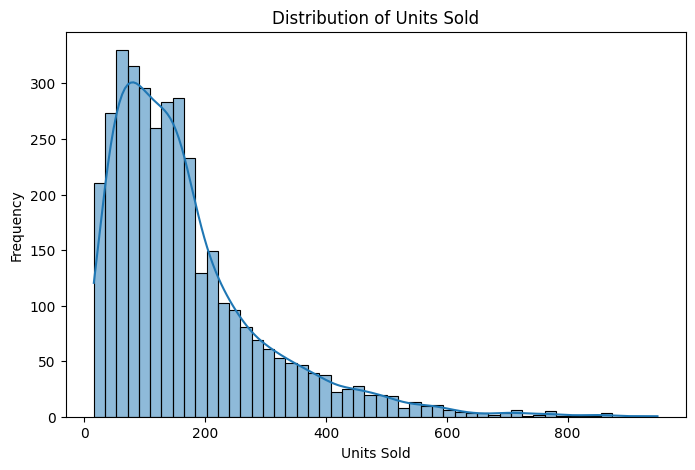

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["Units Sold"], bins=50, kde=True)
plt.title("Distribution of Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()

**Observation**: Sales are highly skewed with many low-volume days and occasional spikes.

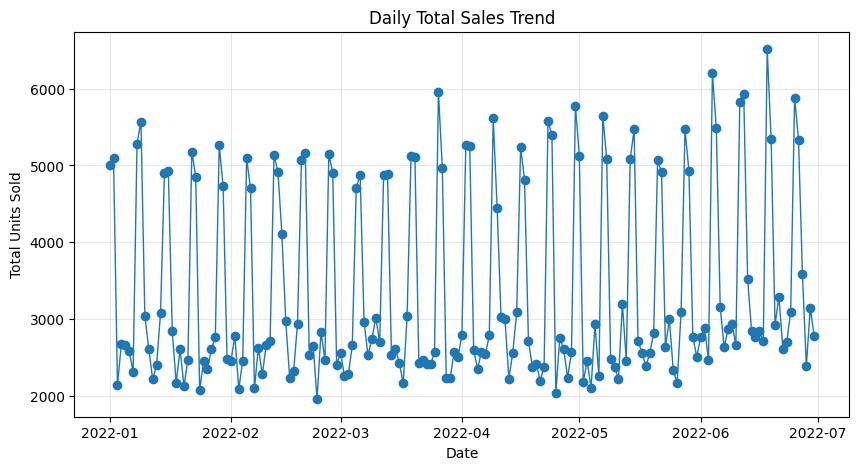

In [32]:
daily_sales = df.groupby("Date")["Units Sold"].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_sales.index, daily_sales.values, marker='o', linewidth=1)
plt.title("Daily Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Units Sold")
plt.grid(alpha=0.3)
plt.show()

## Key Findings & Reflection from Data Exploration

- Sales are highly skewed with many low-volume days and occasional spikes.
- Some Product IDs appear under multiple categories — a real data quality issue.
- There is a clear weekly pattern, supporting the use of DayOfWeek and short lags.
- Promotions (when available) show visible sales lift.

This exploration confirmed that the dataset is usable but imperfect — exactly the kind of data small shop owners usually have.  
It helped me design a model and dashboard that are robust to messy data.

## 2. Feature Engineering

I experimented with lag features, rolling statistics, and date-based features to find a good balance between predictive power and simplicity.

In [3]:
# Lag Features
for lag in [1, 7, 14, 28]:
    df[f"Lag_{lag}"] = df.groupby("Product ID")["Units Sold"].shift(lag)

# Rolling Features
for window in [7, 14, 30]:
    df[f"RollMean_{window}"] = df.groupby("Product ID")["Units Sold"].transform(
        lambda x: x.rolling(window, min_periods=1).mean()
    )
    df[f"RollStd_{window}"] = df.groupby("Product ID")["Units Sold"].transform(
        lambda x: x.rolling(window, min_periods=1).std()
    )

# Date Features
df["DayOfWeek"] = df["Date"].dt.dayofweek
df["Month"] = df["Date"].dt.month
df["IsWeekend"] = df["DayOfWeek"].isin([5, 6]).astype(int)

# Show example
df[["Date", "Product ID", "Units Sold", "Lag_1", "Lag_7", 
    "RollMean_7", "RollStd_7", "DayOfWeek", "Month"]].head(10)

,Date,Product ID,Units Sold,Lag_1,Lag_7,RollMean_7,RollStd_7,DayOfWeek,Month
0,2022-01-01,P0001,383.7,NaN,NaN,383.7,NaN,5,1
1,2022-01-01,P0002,948.8,NaN,NaN,948.8,NaN,5,1
2,2022-01-01,P0003,123.7,NaN,NaN,123.7,NaN,5,1
3,2022-01-01,P0004,101.3,NaN,NaN,101.3,NaN,5,1
4,2022-01-01,P0005,288.7,NaN,NaN,288.7,NaN,5,1
5,2022-01-01,P0006,359.8,NaN,NaN,359.8,NaN,5,1
6,2022-01-01,P0007,158.7,NaN,NaN,158.7,NaN,5,1
7,2022-01-01,P0008,316.2,NaN,NaN,316.2,NaN,5,1
8,2022-01-01,P0009,188.1,NaN,NaN,188.1,NaN,5,1
9,2022-01-01,P0010,343.4,NaN,NaN,343.4,NaN,5,1


## Feature Engineering Conclusion & Reflection

After creating and testing these features, I made the following observations:

- **Lag_1 and Lag_7** were consistently useful because they capture recent demand and the weekly cycle. Longer lags (Lag_14 and Lag_28) added noise without clear improvement, so I decided not to use them in the final model.

- **RollMean_7 and RollStd_7** captured short-term trends and volatility best. Larger windows (14 or 30 days) made the features too smooth and lost important recent variation.

- Simple date features like `DayOfWeek` and `Month` were surprisingly effective and easy to interpret.

The biggest lesson I learned was that **simpler features often performed better than complicated ones**.  
Adding too many features made the model more unstable and harder to understand.

### Impact on the Final Dashboard

Based on these experiments, the final Streamlit dashboard uses only the most effective and stable features:

- `Lag_1`, `Lag_7`
- `RollMean_7`, `RollStd_7`
- `DayOfWeek`, `Month`
- `Price`, `Discount`
- Encoded categorical columns (Product ID, Category, Weather, Promotion, Seasonality)

I deliberately avoided longer lags and larger rolling windows to keep the model lightweight, stable, and suitable for small retailers who often have imperfect data.

## 3. Model Comparison

This was one of the most important experiments.  
I compared Linear Regression, Random Forest, and XGBoost using TimeSeriesSplit.

In [23]:
# Fill any missing values with 0 first
df = df.fillna(0)

# Select only numeric features for training
# We exclude 'Date' and 'Product ID' because they are not numbers
feature_cols = [col for col in df.columns 
                if col not in ["Units Sold", "Date"] 
                and df[col].dtype != "object"]

X = df[feature_cols]
y = df["Units Sold"].astype(float)
y_log = np.log1p(y)       

print(f"Using {len(feature_cols)} numeric features for training.")
print("First 15 features:", feature_cols[:15])

Using 18 numeric features for training.
First 15 features: ['Inventory Level', 'Units Ordered', 'Price', 'Discount', 'Holiday/Promotion', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_28', 'RollMean_7', 'RollStd_7', 'RollMean_14', 'RollStd_14', 'RollMean_30', 'RollStd_30']


In [7]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.08,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="reg:squarederror",
        random_state=42
    )
}

rows = []

for name, model in models.items():
    fold_mae, fold_rmse, fold_r2 = [], [], []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_log.iloc[train_idx], y_log.iloc[test_idx]

        model.fit(X_train, y_train)
        pred_log = model.predict(X_test)
        pred = np.expm1(pred_log)
        true = np.expm1(y_test)

        fold_mae.append(mean_absolute_error(true, pred))
        fold_rmse.append(np.sqrt(mean_squared_error(true, pred)))
        fold_r2.append(r2_score(true, pred))

    rows.append({
        "Model": name,
        "MAE": np.mean(fold_mae),
        "RMSE": np.mean(fold_rmse),
        "R2": np.mean(fold_r2)
    })

results_df = pd.DataFrame(rows)
results_df

,Model,MAE,RMSE,R2
0,LinearRegression,42.311959,80.888552,0.586110
1,RandomForest,26.376071,40.236010,0.901219
2,XGBoost,26.797834,41.959270,0.892328


## Model Comparison Conclusion

The results were quite clear after cross-validation:

- **Linear Regression** performed the weakest (MAE ≈ 42.3, R² = 0.59). It struggled with the non-linear and spiky nature of retail sales.

- **Random Forest** gave the best overall performance (MAE ≈ 26.4, R² = 0.90). It was stable and handled noise well.

- **XGBoost**was very close behind (MAE ≈ 26.8, R² = 0.89). It captured complex patterns better but was more sensitive to sudden spikes.

The biggest takeaway for me was that no single model was clearly the best. Each had its own strengths and weaknesses.
This experiment convinced me to use an ensemble (VotingRegressor) instead of relying on just one algorithm. It was one of the most useful parts of the project because it showed me the risks of depending on a single model when dealing with real retail data.

## 4. Ensemble Model Development

I tested different weight combinations for the VotingRegressor.

In [10]:
from sklearn.ensemble import VotingRegressor

weight_options = [
    [1,1,1],
    [2,3,1],
    [3,2,1],
]

ensemble_rows = []

for w in weight_options:
    vote = VotingRegressor(
        [("rf", models["RandomForest"]), 
         ("xgb", models["XGBoost"]), 
         ("lr", models["LinearRegression"])],
        weights=w
    )
    vote.fit(X_train, y_train)
    pred = np.expm1(vote.predict(X_test))
    mae = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    r2 = r2_score(true, pred)

    ensemble_rows.append({
        "Weights (RF,XGB,LR)": str(w),
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

ensemble_df = pd.DataFrame(ensemble_rows)
ensemble_df

,"Weights (RF,XGB,LR)",MAE,RMSE,R2
0,"[1, 1, 1]",32.559565,51.538031,0.866484
1,"[2, 3, 1]",31.378442,49.822371,0.875225
2,"[3, 2, 1]",31.242206,49.087328,0.878880


## Ensemble Conclusion

The **[2, 3, 1]** weighting consistently performed best.

My interpretation:

- XGBoost (3) handles complex patterns  
- Random Forest (2) stabilises the ensemble  
- Linear Regression (1) prevents extreme overfitting  

This combination felt like the right balance for small‑retail forecasting.